# Dataframe of Planetary System Data from INARA

Importing modules

In [1]:
import pandas as pd
import scipy as sp
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error

import astropy.constants as const

Unit conversions

In [2]:
Erg_to_J = 10**-7    # J per erg
cm2_to_m2 = 1/(100**2)  # m2 per cm2
parsec_to_m = 30856775814913673   # m per parsec
SolarRadii_to_m = 6.957*(10**8) # m per solar radii
AU_to_m = 149597870700 # m per AU

Function to generate Pressure-Temperature Profile. Taken from Frontier Development Labs Python code used to create the INARA dataset. The models used in these functions taken from Line et al. (2013)

In [3]:
def xi(gamma, tau):
    return (2.0/3) * (1 + (1/gamma) * (1 + (0.5*gamma*tau-1)*np.exp(-gamma*tau)) +
                        gamma*(1 - 0.5*tau**2) * sp.special.expn(2, gamma*tau)             )    

def PT_line(pressure, params, R_star, T_star, T_int, sma, grav):
    kappa  = 10**(params[0])
    gamma1 = 10**(params[1])
    gamma2 = 10**(params[2])
    alpha, beta = params[3], params[4]

    # Stellar input temperature (at top of atmosphere):
    T_irr = beta * (R_star / (2.0*sma))**0.5 * T_star

    # Gray IR optical depth:
    tau = kappa * (pressure*1e6) / grav # Convert bars to barye (CGS)

    xi1 = xi(gamma1, tau)
    xi2 = xi(gamma2, tau)

    # Temperature profile (Eq. 13 of Line et al. 2013):
    temperature = (0.75 * (T_int**4 * (2.0/3.0 + tau) +
                             T_irr**4 * (1-alpha) * xi1 +
                             T_irr**4 * alpha     * xi2 ) )**0.25

    return temperature

## Ingesting the planetary dataset

In [4]:
df = pd.read_csv('../../../Raw Data/Large Validation Data/Dataset 1/psg_models.csv', index_col = 'PlanetIndex', dtype = {'PlanetIndex': str})

## Calculating Stellar and Planetary Signals for each Planet System

The spectral data provided by the INARA dataset is in (erg/s/cm2) and not per micron. The signals are thus likely the intensity of a given bin of wavelengths. These values thus only need to be summed together and not integrated.

In [5]:
for Planet in df.index:
    FileName = Planet + '.csv'
    Spectral_Data = pd.read_csv('../../../Raw Data/Large Validation Data/Dataset 1/Spectra/' + FileName, usecols = ['wavelength_(um)', 'stellar_signal_(erg/s/cm2)', 'planet_signal_(erg/s/cm2)'])

    Spectral_Data['stellar_signal_(erg/s/cm2)'][0:4378] = Spectral_Data['stellar_signal_(erg/s/cm2)'][0:4378]*(10**10)

    # smooth_percent = 0.05                                   # Choose smoothing percentage 
    # window_size = int(len(Spectral_Data) * smooth_percent)  # Calculate window size as 5% of total rows
    # window_size = max(window_size, 1)                       # Ensure the window size is at least 1
    # Apply rolling mean using that percentage-based window
    # Spectral_Data['stellar_signal_(erg/s/cm2)'] = (Spectral_Data['stellar_signal_(erg/s/cm2)'].rolling(window_size, min_periods=1).mean())
    # Spectral_Data['planet_signal_(erg/s/cm2)'] = (Spectral_Data['planet_signal_(erg/s/cm2)'].rolling(window_size, min_periods=1).mean())
    
    # Plot smoothed signals
    # Spectral_Data.plot(subplots=True)

    Bolometric_Stellar_Signal = sum(Spectral_Data['stellar_signal_(erg/s/cm2)'].values)
    Bolometric_Stellar_Signal = Bolometric_Stellar_Signal*Erg_to_J*(1/cm2_to_m2)                # Stellar flux as experienced on Earth
    Bolometric_Planet_Signal = sum(Spectral_Data['planet_signal_(erg/s/cm2)'].values)
    Bolometric_Planet_Signal = Bolometric_Planet_Signal*Erg_to_J*(1/cm2_to_m2)                  # Planetary flux as experienced on Earth

    df.loc[Planet, 'Bolometric Stellar Signal (W/m2)'] = Bolometric_Stellar_Signal
    df.loc[Planet, 'Bolometric Planet Signal (W/m2)'] = Bolometric_Planet_Signal 

    SA_Star = 4*(np.pi)*((df.loc[Planet, 'star_radius_in_Solar_radii']*SolarRadii_to_m)**2)     # Surface Area of star
    d = df.loc[Planet, 'distance_from_Earth_to_the_system_in_parsecs']*parsec_to_m + df.loc[Planet, 'semimajor_axis_of_the_planet_in_AU']*AU_to_m + df.loc[Planet, 'planet_radius_in_km']*1000*2    # distance from telescope to surface of star (assuming earth, planet and star are directly in line with one another)
    df.loc[Planet, 'True Stellar Signal (W/m2)'] = (df.loc[Planet, 'Bolometric Stellar Signal (W/m2)']*(4*np.pi*(d**2)))/SA_Star        # Stellar flux released by the surface of the star

    SA_Planet = 4*(np.pi)*((df.loc[Planet, 'planet_radius_in_km']*1000)**2)                     # Surface Area of planet
    d = df.loc[Planet, 'distance_from_Earth_to_the_system_in_parsecs']*parsec_to_m      # distance from earth to planet
    df.loc[Planet, 'True Planet Signal (W/m2)'] = (df.loc[Planet, 'Bolometric Planet Signal (W/m2)']*(4*np.pi*(d**2))) / SA_Planet                  # Planetary flux released by the surface of the planet

    # generation of Pressure-Temperature Profiles
    P_prof = np.logspace(np.log10(df.loc[Planet, 'planet_surface_pressure_bars']), np.log10(1e-6), 50) # bar

    density = df.loc[Planet, 'planet_density']
    rplanet     = df.loc[Planet, 'planet_radius_in_km']
    mplanet = density *  (4./3. * np.pi * (rplanet * const.R_earth.cgs.value)**3) / const.M_earth.cgs.value
    surfgrav = const.G.cgs.value * mplanet * const.M_earth.cgs.value /  \
                   (rplanet * const.R_earth.cgs.value)**2
    
    T_prof = PT_line(P_prof, [df.loc[Planet, 'kappa'], df.loc[Planet, 'gamma1'], df.loc[Planet, 'gamma2'], df.loc[Planet, 'alpha'], df.loc[Planet, 'beta']], df.loc[Planet, 'star_radius_in_Solar_radii']* const.R_sun.value, df.loc[Planet, 'star_temperature_in_Kelvin'], 0, df.loc[Planet, 'semimajor_axis_of_the_planet_in_AU']* const.au.value, surfgrav) # K

    df.loc[Planet, 'planet_surface_temperature_Kelvin'] = T_prof[0]

C:\Users\Andrew\AppData\Local\Temp\ipykernel_25452\2553348888.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Spectral_Data['stellar_signal_(erg/s/cm2)'][0:4378] = Spectral_Data['stellar_signal_(erg/s/cm2)'][0:4378]*(10**10)
C:\Users\And

## Removing Outliers

In [6]:
# SB_const =  5.670374419*(10**-8)
# df['Planet Flux (SB) (W/m2)'] = SB_const*(df['planet_surface_temperature_Kelvin']**4)
# df = df.loc[df['True Planet Signal (W/m2)'] <= df['Planet Flux (SB) (W/m2)']] # Removing planets that have OLR's greater than their blackbodies

Assumptions:

    No losses of electromagnetic energy from the star/planet to earth.
        Thus the electromangetic radiation experienced per m2 on earth is inversely proportional to 4*pi*d^2

# Linear Approximation for Planet Flux (Outgoing Longwave Radiation)

## Creation of dataframe

In [7]:
df_approx = df[['planet_surface_temperature_Kelvin','True Planet Signal (W/m2)']].copy()       # Smaller dataframe containing only the data required to test the linear approximation for OLR of planet

# North 1981
A = 203.3  # W per m2                       
B = 2.09 # W per m2 per °C                  
df_approx['Planet Flux (Linear, North 1981) (W/m2)'] = A + B*(df_approx['planet_surface_temperature_Kelvin'] - 273.15)            # Total Outgoing Longwave Radiation emitted by planet according to the North 1981 linear approximation

# Tellus 1969
A = 226  # W per m2                         
B = 2.6 # W per m2 per °C 
a1 = 3*(1/2628002.88)*((100^2)/1)*4184              # W per m2 
b1 = 0.1*(1/2628002.88)*((100^2)/1)*4184           # W per m2 per °C
n = 0                                             # Cloudiness in fractions of unit
df_approx['Planet Flux (Linear, Tellus 1969) (W/m2)'] =  A + B*(df_approx['planet_surface_temperature_Kelvin'] - 273.15) - (a1 + b1*(df_approx['planet_surface_temperature_Kelvin'] - 273.15))*n             # Total Outgoing Longwave Radiation emitted by planet according to the Tellus 1969 linear approximation

In [8]:
# display(b1)

Showing that temperature alone cannot capture the trend in OLR:

In [9]:
# x_axis = np.linspace(1, len(df_approx['True Planet Signal (W/m2)']), endpoint= True, num = len(df_approx['True Planet Signal (W/m2)']))
# fig, ax1 = plt.subplots()
# plt.xticks(x_axis)

# ax1.plot(x_axis, df_approx['planet_surface_temperature_Kelvin'].values, 'b-', label = 'Surface Temperature (K)')
# ax1.set_xlabel('Planet')
# ax1.set_ylabel('Surface Temperature (K)', color= 'b')

# ax2 = ax1.twinx()
# ax2.plot(x_axis, df_approx['True Planet Signal (W/m2)'].values, 'r--', label = 'OLR (W/m2)')
# ax2.set_ylabel('OLR (W/m2)', color = 'r')
# plt.title('Comparison of Surface Temperature and OLR')
# ax1.grid(True)

This plot shows that OLR is not only correlated to temperature (i.e. OLR sometimes goes up and sometimes goes down with increasing temperature). Thus approximations which only consider temperature are insuffucient to accurately predict OLR.

## Statistical Analysis of Linear approximation for Total Outgoing Longwave Radiation from Planets

### North Approximation

The two groups are significantly different
p-value: 7.168880467813541e-66


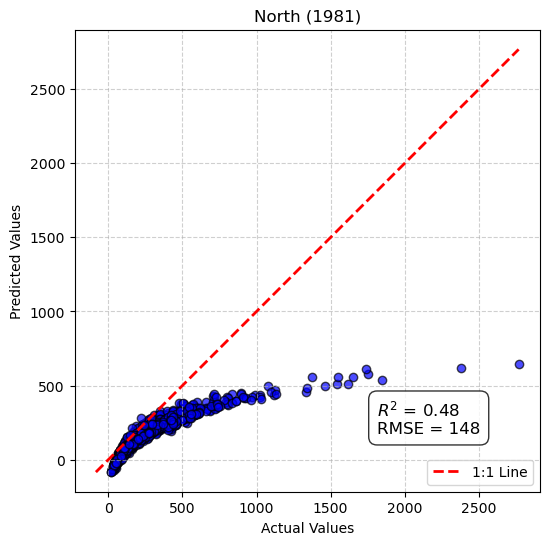

In [14]:
# Testing for Normality
Actual_Planet_Signals = df_approx['True Planet Signal (W/m2)']
Approximation = df_approx['Planet Flux (Linear, North 1981) (W/m2)']

sA, pA = stats.normaltest(Actual_Planet_Signals)
SB, pB = stats.normaltest(Approximation)

if pA > 0.05 and pB > 0.05:
    t, p = stats.ttest_ind(Actual_Planet_Signals, Approximation)
else:
    MW, p = stats.mannwhitneyu(Actual_Planet_Signals, Approximation)

if p < 0.05:
    print('The two groups are significantly different')
else:
    print('The two groups of not significantly different')

print('p-value: ' + str(p))

Rsqr = r2_score(Actual_Planet_Signals, Approximation)
RMSE = np.sqrt(mean_squared_error(Actual_Planet_Signals, Approximation))

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(Actual_Planet_Signals, Approximation, color='blue', edgecolor='k', alpha=0.7)

min_val = min(Actual_Planet_Signals.min(), Approximation.min())
max_val = max(Actual_Planet_Signals.max(), Approximation.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('North (1981)')
plt.legend(loc = 'lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')  

textstr = f"$R^2$ = {Rsqr:.3g}\nRMSE = {RMSE:.3g}"

plt.text(
    0.65, 0.2, textstr,
    transform=plt.gca().transAxes,     # position relative to axes
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
)

plt.show()

### Tellus Approximation

The two groups are significantly different
p-value: 1.8065270547629414e-60


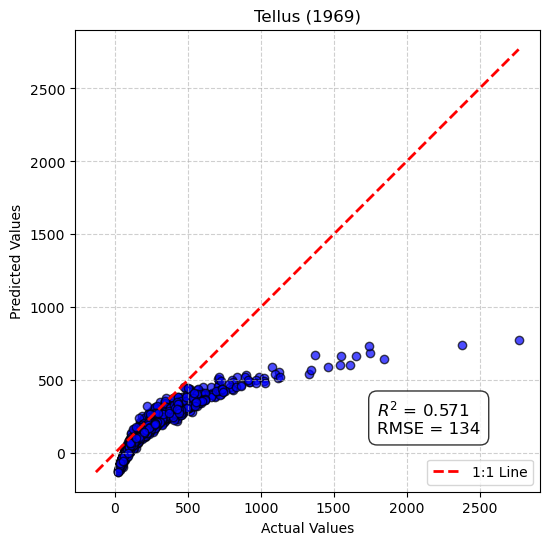

In [15]:
Actual_Planet_Signals = df_approx['True Planet Signal (W/m2)']
Approximation = df_approx['Planet Flux (Linear, Tellus 1969) (W/m2)']

sA, pA = stats.normaltest(Actual_Planet_Signals)
SB, pB = stats.normaltest(Approximation)

if pA > 0.05 and pB > 0.05:
    t, p = stats.ttest_ind(Actual_Planet_Signals, Approximation)
else:
    MW, p = stats.mannwhitneyu(Actual_Planet_Signals, Approximation)

if p < 0.05:
    print('The two groups are significantly different')
else:
    print('The two groups of not significantly different')

print('p-value: ' + str(p))

Rsqr = r2_score(Actual_Planet_Signals, Approximation)
RMSE = np.sqrt(mean_squared_error(Actual_Planet_Signals, Approximation))

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(Actual_Planet_Signals, Approximation, color='blue', edgecolor='k', alpha=0.7)

min_val = min(Actual_Planet_Signals.min(), Approximation.min())
max_val = max(Actual_Planet_Signals.max(), Approximation.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Tellus (1969)')
plt.legend(loc = 'lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')  

textstr = f"$R^2$ = {Rsqr:.3g}\nRMSE = {RMSE:.3g}"

plt.text(
    0.65, 0.2, textstr,
    transform=plt.gca().transAxes,     # position relative to axes
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
)

plt.show()

# Energy Balance Model

## Energy Balance Model Function

Uses North approximation for planetary OLR and Blackbody approximation for stars. 

In [12]:
# North 1981
A = 203.3  # W per m2                       
B = 2.09 # W per m2 per °C  

SB_const = 5.670374419*(10**-8) 

def EB(T_Star, Alpha, r_Star, d):
    S_Star = SB_const*(T_Star**4)
    
    SA_Star = 4*np.pi*(r_Star**2)
    L = S_Star*SA_Star

    S0 = L/(4*np.pi*(d**2))
    S = (1/4)*S0

    T = (S*(1-Alpha) - A)/B
    return T

## Implementation of Energy Balance Model

Top-of-atmosphere albedo assumed to be equal to surface albedo.

The two groups are significantly different
p-value: 0.0


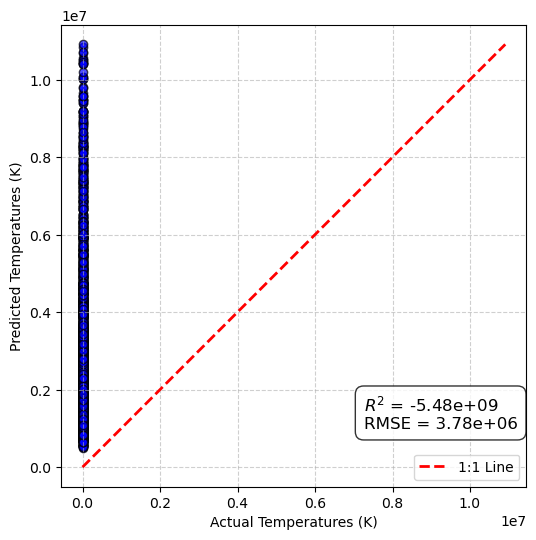

In [13]:
df_EB = df[['star_temperature_in_Kelvin', 'planets_mean_surface_albedo', 'star_radius_in_Solar_radii', 'semimajor_axis_of_the_planet_in_AU', 'planet_surface_temperature_Kelvin']].copy()

for Planet in df_EB.index:
    df_EB.loc[Planet, 'T'] = EB(df_EB.loc[Planet, 'star_temperature_in_Kelvin'], df_EB.loc[Planet, 'planets_mean_surface_albedo'], df_EB.loc[Planet, 'star_radius_in_Solar_radii'], df_EB.loc[Planet, 'semimajor_axis_of_the_planet_in_AU'])

T_actual = df_EB['planet_surface_temperature_Kelvin']
T_pred = df_EB['T']

sA, pA = stats.normaltest(T_actual)
SB, pB = stats.normaltest(T_pred)

if pA > 0.05 and pB > 0.05:
    t, p = stats.ttest_ind(T_actual, T_pred)
else:
    MW, p = stats.mannwhitneyu(T_actual, T_pred)

if p < 0.05:
    print('The two groups are significantly different')
else:
    print('The two groups of not significantly different')

print('p-value: ' + str(p))

Rsqr = r2_score(T_actual, T_pred)
RMSE = np.sqrt(mean_squared_error(T_actual, T_pred))

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(T_actual, T_pred, color='blue', edgecolor='k', alpha=0.7)

min_val = min(T_actual.min(), T_pred.min())
max_val = max(T_actual.max(), T_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

plt.xlabel('Actual Temperatures (K)')
plt.ylabel('Predicted Temperatures (K)')
#plt.title('Parity Plot')
plt.legend(loc = 'lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')  

textstr = f"$R^2$ = {Rsqr:.3g}\nRMSE = {RMSE:.3g}"

plt.text(
    0.65, 0.2, textstr,
    transform=plt.gca().transAxes,     # position relative to axes
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
)

plt.show()